Training loop in Vanilla PyTorch


In [1]:
# step 1 - imports

import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# step 2 - device and transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
# transforms converts the data into a tensor and normalizes it
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

In [3]:
# step 3 - loading the datasets

train_ds = datasets.MNIST("data", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST("data", train=False, download=True, transform=tfm)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64) # DataLoader is an iterable over the dataset, allows for 'streaming'

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


In [4]:
# step 4 - defining the model as a class (subclassing nn.Module)

class Net(nn.Module):
    def __init__(self):                 # define layers
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x):               # define data flow
        return self.net(x)

model = Net().to(device)

In [5]:
# step 5 - loss function + optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [6]:
# step 6 -training loop/ learning

def train():
    model.train()
    total = 0
    for X, y in train_dl:
        X, y = X.to(device), y.to(device)
        loss = loss_fn(model(X), y)   # 1. forward + loss
        optimizer.zero_grad()         # 2. clear old gradients
        loss.backward()               # 3. backprop
        optimizer.step()              # 4. update weights
        total += loss.item()
    return total / len(train_dl)

In [7]:
# step 7 - testing loop

def test():
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dl:
            X, y = X.to(device), y.to(device)
            out = model(X)
            total += loss_fn(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
    return total / len(test_dl), correct / len(test_ds)

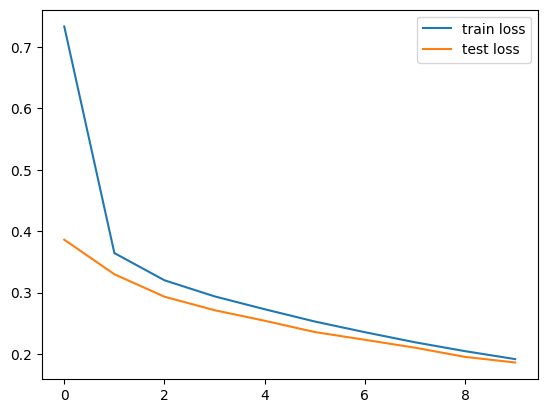

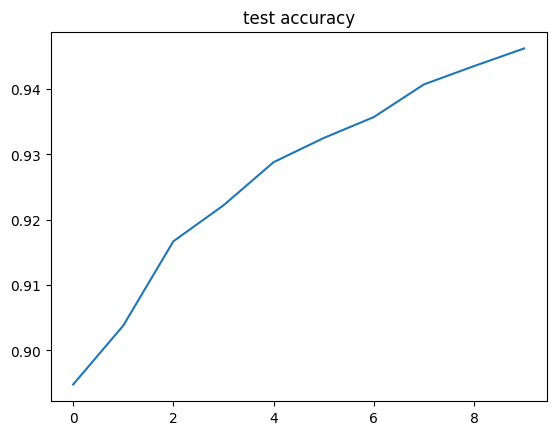

In [8]:
# step 8 - graphs of results

train_losses, test_losses, accs = [], [], []
for epoch in range(10):
    train_losses.append(train())
    tl, acc = test()
    test_losses.append(tl); accs.append(acc)

plt.plot(train_losses, label="train loss"); plt.plot(test_losses, label="test loss")
plt.legend(); plt.show()
plt.plot(accs); plt.title("test accuracy"); plt.show()